This notebook implements logistic regression

In [16]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report, 
                             roc_curve, roc_auc_score, precision_recall_curve)
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

Data Loading

In [17]:
# Load the dataset
df = pd.read_csv('data.csv')

# Display basic information
print(f"Dataset shape: {df.shape}")
print(f"\nFirst few rows:")
df.head()

Dataset shape: (569, 33)

First few rows:


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


Data cleaning and formatting

In [18]:
# Removing unecessary columns from the dataset
df = df.drop(['id','Unnamed: 32'],axis=1)

In [19]:
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [20]:
# Encode diagnosis: M = 1 (Malignant), B = 0 (Benign)
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})
print("Diagnosis encoding: M -> 1 (Malignant), B -> 0 (Benign)")

# Separate features and target
X = df.drop(['diagnosis'], axis=1)
y = df['diagnosis']

print(f"\nFeatures (X): {X.shape}")
print(f"Target (y): {y.shape}")

# Split into train, validation, and test sets
# First split: 80% temp (train+val), 20% test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Second split: 75% train, 25% validation (from the 80%)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
)

print(f"\nData Split:")
print(f"Training set:   {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Validation set: {X_val.shape[0]} samples ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"Test set:       {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)")

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(f"\n Features scaled using StandardScaler")

Diagnosis encoding: M -> 1 (Malignant), B -> 0 (Benign)

Features (X): (569, 30)
Target (y): (569,)

Data Split:
Training set:   341 samples (59.9%)
Validation set: 114 samples (20.0%)
Test set:       114 samples (20.0%)

 Features scaled using StandardScaler


In [21]:
# Train baseline model with default parameters
lr_baseline = LogisticRegression(random_state=42, max_iter=10000)
lr_baseline.fit(X_train_scaled, y_train)

# Make predictions
y_train_pred = lr_baseline.predict(X_train_scaled)
y_val_pred = lr_baseline.predict(X_val_scaled)
y_test_pred = lr_baseline.predict(X_test_scaled)

# Evaluate on all sets
train_acc = accuracy_score(y_train, y_train_pred)
val_acc = accuracy_score(y_val, y_val_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print("Baseline Model Performance:")
print(f"Training Accuracy:   {train_acc:.4f} ({train_acc*100:.2f}%)")
print(f"Validation Accuracy: {val_acc:.4f} ({val_acc*100:.2f}%)")
print(f"Test Accuracy:       {test_acc:.4f} ({test_acc*100:.2f}%)")

# Detailed classification report (on test set)
print(f"\nClassification Report (Test Set):")
print(classification_report(y_test, y_test_pred, 
                          target_names=['Benign (0)', 'Malignant (1)']))

Baseline Model Performance:
Training Accuracy:   0.9883 (98.83%)
Validation Accuracy: 0.9737 (97.37%)
Test Accuracy:       0.9737 (97.37%)

Classification Report (Test Set):
               precision    recall  f1-score   support

   Benign (0)       0.97      0.99      0.98        72
Malignant (1)       0.98      0.95      0.96        42

     accuracy                           0.97       114
    macro avg       0.97      0.97      0.97       114
 weighted avg       0.97      0.97      0.97       114



In [22]:
# Define parameter grid
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000],  # Regularization strength
    'penalty': ['l1', 'l2'],                      # Regularization type
    'solver': ['liblinear', 'saga']               # Optimization algorithm
}

print("Testing hyperparameter combinations...")
print(f"Total combinations: {len(param_grid['C']) * len(param_grid['penalty']) * len(param_grid['solver'])}")

# Manual grid search using validation set
best_score = 0
best_params = {}
results = []

for C in param_grid['C']:
    for penalty in param_grid['penalty']:
        for solver in param_grid['solver']:
            try:
                model = LogisticRegression(C=C, penalty=penalty, solver=solver, 
                                          random_state=42, max_iter=10000)
                model.fit(X_train_scaled, y_train)
                val_score = accuracy_score(y_val, model.predict(X_val_scaled))
                
                results.append({
                    'C': C,
                    'penalty': penalty,
                    'solver': solver,
                    'val_accuracy': val_score
                })
                
                if val_score > best_score:
                    best_score = val_score
                    best_params = {'C': C, 'penalty': penalty, 'solver': solver}
            except:
                continue

# Show top 5 combinations
results_df = pd.DataFrame(results).sort_values('val_accuracy', ascending=False)
print("\nTop 5 Hyperparameter Combinations:")
print(results_df.head(5).to_string(index=False))

print(f"\n Best Hyperparameters (based on validation set):")
print(f"  C: {best_params['C']}")
print(f"  Penalty: {best_params['penalty']}")
print(f"  Solver: {best_params['solver']}")
print(f"  Validation Accuracy: {best_score:.4f}")

# Train final model with best parameters
lr_optimized = LogisticRegression(**best_params, random_state=42, max_iter=10000)
lr_optimized.fit(X_train_scaled, y_train)
print("\n Optimized model trained")

Testing hyperparameter combinations...
Total combinations: 28

Top 5 Hyperparameter Combinations:
  C penalty    solver  val_accuracy
0.1      l2 liblinear      0.982456
0.1      l2      saga      0.982456
0.1      l1      saga      0.973684
1.0      l2      saga      0.973684
1.0      l2 liblinear      0.973684

 Best Hyperparameters (based on validation set):
  C: 0.1
  Penalty: l2
  Solver: liblinear
  Validation Accuracy: 0.9825

 Optimized model trained


In [23]:
# Get predictions from optimized model
y_train_pred_opt = lr_optimized.predict(X_train_scaled)
y_val_pred_opt = lr_optimized.predict(X_val_scaled)
y_test_pred_opt = lr_optimized.predict(X_test_scaled)
y_test_proba = lr_optimized.predict_proba(X_test_scaled)[:, 1]

# Calculate accuracies
train_acc_opt = accuracy_score(y_train, y_train_pred_opt)
val_acc_opt = accuracy_score(y_val, y_val_pred_opt)
test_acc_opt = accuracy_score(y_test, y_test_pred_opt)

print("Optimized Model Performance:")
print(f"Training Accuracy:   {train_acc_opt:.4f} ({train_acc_opt*100:.2f}%)")
print(f"Validation Accuracy: {val_acc_opt:.4f} ({val_acc_opt*100:.2f}%)")
print(f"Test Accuracy:       {test_acc_opt:.4f} ({test_acc_opt*100:.2f}%)")

# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred_opt)
tn, fp, fn, tp = cm.ravel()

print(f"\nConfusion Matrix:")
print(f"                  Predicted")
print(f"              Benign  Malignant")
print(f"Actual Benign    {tn:3d}      {fp:3d}")
print(f"       Malignant {fn:3d}      {tp:3d}")

# Detailed metrics
accuracy = (tp + tn) / (tp + tn + fp + fn)
sensitivity = tp / (tp + fn)  # Recall for malignant
specificity = tn / (tn + fp)  # Recall for benign
precision = tp / (tp + fp)
f1 = f1_score(y_test, y_test_pred_opt)
misclass_rate = (fp + fn) / (tp + tn + fp + fn)

print(f"\nDetailed Metrics:")
print(f"Accuracy:              {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Sensitivity (Recall):  {sensitivity:.4f} - Malignant detection rate")
print(f"Specificity:           {specificity:.4f} - Benign detection rate")
print(f"Precision:             {precision:.4f} - Positive predictive value")
print(f"F1-Score:              {f1:.4f}")
print(f"Misclassification:     {misclass_rate:.4f} ({misclass_rate*100:.2f}%)")

# ROC-AUC
roc_auc = roc_auc_score(y_test, y_test_proba)
print(f"ROC-AUC Score:         {roc_auc:.4f}")

print(f"\n  Clinical Significance:")
print(f"False Negatives: {fn} - Missed cancer cases")
print(f"False Positives: {fp} ")

Optimized Model Performance:
Training Accuracy:   0.9824 (98.24%)
Validation Accuracy: 0.9825 (98.25%)
Test Accuracy:       0.9825 (98.25%)

Confusion Matrix:
                  Predicted
              Benign  Malignant
Actual Benign     72        0
       Malignant   2       40

Detailed Metrics:
Accuracy:              0.9825 (98.25%)
Sensitivity (Recall):  0.9524 - Malignant detection rate
Specificity:           1.0000 - Benign detection rate
Precision:             1.0000 - Positive predictive value
F1-Score:              0.9756
Misclassification:     0.0175 (1.75%)
ROC-AUC Score:         0.9977

  Clinical Significance:
False Negatives: 2 - Missed cancer cases
False Positives: 0 


In [25]:
bias = 1 - train_acc_opt
variance = train_acc_opt - test_acc_opt

print("Bias-Variance Analysis:")
print(f"Training Accuracy: {train_acc_opt:.4f}")
print(f"Test Accuracy:     {test_acc_opt:.4f}")
print(f"\nBias (1 - Training Acc):       {bias:.4f}")
print(f"Variance (Train Acc - Test Acc): {variance:.4f}")

print(f"\n Interpretation:")
if bias < 0.05 and abs(variance) < 0.03:
    print(" WELL-FITTED MODEL")
    print("  - Low bias: Model captures patterns well")
    print("  - Low variance: Model generalizes well")
    print("  - No overfitting or underfitting detected")
elif bias < 0.05 and variance > 0.03:
    print("  OVERFITTING DETECTED")
    print("  - Low bias: Fits training data well")
    print("  - High variance: Poor generalization")
    print("  - Recommendation: Increase regularization or get more data")
elif bias > 0.05:
    print("  UNDERFITTING DETECTED")
    print("  - High bias: Model too simple")
    print("  - Recommendation: Reduce regularization or add features")
else:
    print(" Acceptable performance")

# Learning curves
print(f"\nLearning Curve Analysis:")
train_sizes = [0.2, 0.4, 0.6, 0.8, 1.0]
train_scores_lc = []
val_scores_lc = []

for size in train_sizes:
    n_samples = int(len(X_train_scaled) * size)
    X_subset = X_train_scaled[:n_samples]
    y_subset = y_train[:n_samples]
    
    model_lc = LogisticRegression(**best_params, random_state=42, max_iter=10000)
    model_lc.fit(X_subset, y_subset)
    
    train_scores_lc.append(accuracy_score(y_subset, model_lc.predict(X_subset)))
    val_scores_lc.append(accuracy_score(y_val, model_lc.predict(X_val_scaled)))

for i, size in enumerate(train_sizes):
    print(f"{int(size*100):3d}% data: Train={train_scores_lc[i]:.4f}, Val={val_scores_lc[i]:.4f}")

Bias-Variance Analysis:
Training Accuracy: 0.9824
Test Accuracy:     0.9825

Bias (1 - Training Acc):       0.0176
Variance (Train Acc - Test Acc): -0.0001

 Interpretation:
 WELL-FITTED MODEL
  - Low bias: Model captures patterns well
  - Low variance: Model generalizes well
  - No overfitting or underfitting detected

Learning Curve Analysis:
 20% data: Train=0.9559, Val=0.9737
 40% data: Train=0.9706, Val=0.9649
 60% data: Train=0.9755, Val=0.9825
 80% data: Train=0.9779, Val=0.9825
100% data: Train=0.9824, Val=0.9825


In [31]:
# Get feature coefficients
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr_optimized.coef_[0],
    'Abs_Coefficient': np.abs(lr_optimized.coef_[0])
}).sort_values('Abs_Coefficient', ascending=False)

print("Top 10 Most Important Features:")
print(feature_importance.head(10).to_string(index=False))

print(f"\n Interpretation:")
print("• Positive coefficient -> increases probability of MALIGNANT")
print("• Negative coefficient -> increases probability of BENIGN")
print("• Larger absolute value -> stronger influence on prediction")



Top 10 Most Important Features:
             Feature  Coefficient  Abs_Coefficient
       texture_worst     0.581940         0.581940
 concave points_mean     0.470272         0.470272
        radius_worst     0.459402         0.459402
          area_worst     0.436710         0.436710
     perimeter_worst     0.427497         0.427497
concave points_worst     0.412775         0.412775
      symmetry_worst     0.388989         0.388989
         radius_mean     0.371532         0.371532
           area_mean     0.371045         0.371045
      perimeter_mean     0.363666         0.363666

 Interpretation:
• Positive coefficient -> increases probability of MALIGNANT
• Negative coefficient -> increases probability of BENIGN
• Larger absolute value -> stronger influence on prediction


In [28]:
# Identify misclassified samples
misclassified_idx = np.where(y_test.values != y_test_pred_opt)[0]

print(f"Misclassification Analysis:")
print(f"Total misclassified: {len(misclassified_idx)} out of {len(y_test)}")
print(f"False Positives: {fp} (Benign predicted as Malignant)")
print(f"False Negatives: {fn} (Malignant predicted as Benign) ")

if len(misclassified_idx) > 0:
    # Get misclassified samples
    X_test_reset = X_test.reset_index(drop=True)
    y_test_reset = y_test.reset_index(drop=True)
    
    misclassified_df = X_test_reset.iloc[misclassified_idx].copy()
    misclassified_df['True_Label'] = y_test_reset.iloc[misclassified_idx].values
    misclassified_df['Predicted_Label'] = y_test_pred_opt[misclassified_idx]
    
    print(f"\nMisclassified Sample Statistics:")
    print(misclassified_df[['radius_mean', 'texture_mean', 'area_mean', 
                            'smoothness_mean']].describe())
    
    # Compare with correctly classified
    correct_idx = np.where(y_test.values == y_test_pred_opt)[0]
    correctly_classified_df = X_test_reset.iloc[correct_idx]
    
    print(f"\nFeature Differences (Misclassified vs Correct):")
    diff = misclassified_df.drop(['True_Label', 'Predicted_Label'], axis=1).mean() - \
           correctly_classified_df.mean()
    print(diff.abs().sort_values(ascending=False).head(10))


Misclassification Analysis:
Total misclassified: 2 out of 114
False Positives: 0 (Benign predicted as Malignant)
False Negatives: 2 (Malignant predicted as Benign) 

Misclassified Sample Statistics:
       radius_mean  texture_mean   area_mean  smoothness_mean
count     2.000000      2.000000    2.000000         2.000000
mean     14.460000     16.235000  650.350000         0.094730
std       0.933381      0.629325   93.691649         0.008443
min      13.800000     15.790000  584.100000         0.088760
25%      14.130000     16.012500  617.225000         0.091745
50%      14.460000     16.235000  650.350000         0.094730
75%      14.790000     16.457500  683.475000         0.097715
max      15.120000     16.680000  716.600000         0.100700

Feature Differences (Misclassified vs Correct):
area_worst         61.299107
area_mean          14.429464
area_se            11.890857
perimeter_worst     9.293661
texture_worst       4.293929
perimeter_mean      3.685804
texture_mean        

5-Fold Cross-Validation Results:
Scores: [0.95652174 0.95588235 1.         0.97058824 1.        ]
Mean:   0.9766
Std:    0.0198

 Interpretation:
 Low standard deviation - consistent performance across folds


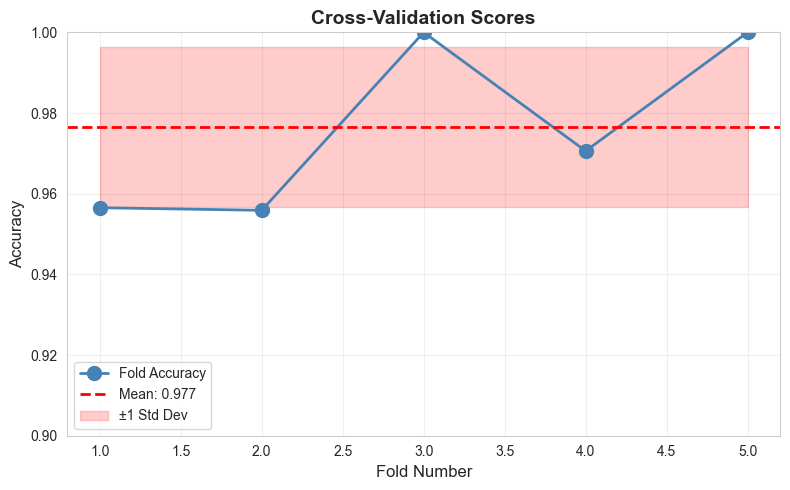

In [29]:
# 5-fold cross-validation on training data
cv_scores = cross_val_score(lr_optimized, X_train_scaled, y_train, 
                           cv=5, scoring='accuracy')

print("5-Fold Cross-Validation Results:")
print(f"Scores: {cv_scores}")
print(f"Mean:   {cv_scores.mean():.4f}")
print(f"Std:    {cv_scores.std():.4f}")

print(f"\n Interpretation:")
if cv_scores.std() < 0.02:
    print(" Low standard deviation - consistent performance across folds")
else:
    print("  High variation - model performance may be unstable")

# Visualize
plt.figure(figsize=(8, 5))
plt.plot(range(1, 6), cv_scores, marker='o', linewidth=2, markersize=10, 
         color='steelblue', label='Fold Accuracy')
plt.axhline(y=cv_scores.mean(), color='red', linestyle='--', linewidth=2,
           label=f'Mean: {cv_scores.mean():.3f}')
plt.fill_between(range(1, 6), 
                 cv_scores.mean() - cv_scores.std(),
                 cv_scores.mean() + cv_scores.std(),
                 alpha=0.2, color='red', label=f'±1 Std Dev')
plt.xlabel('Fold Number', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Cross-Validation Scores', fontweight='bold', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim([0.9, 1.0])
plt.tight_layout()
plt.show()


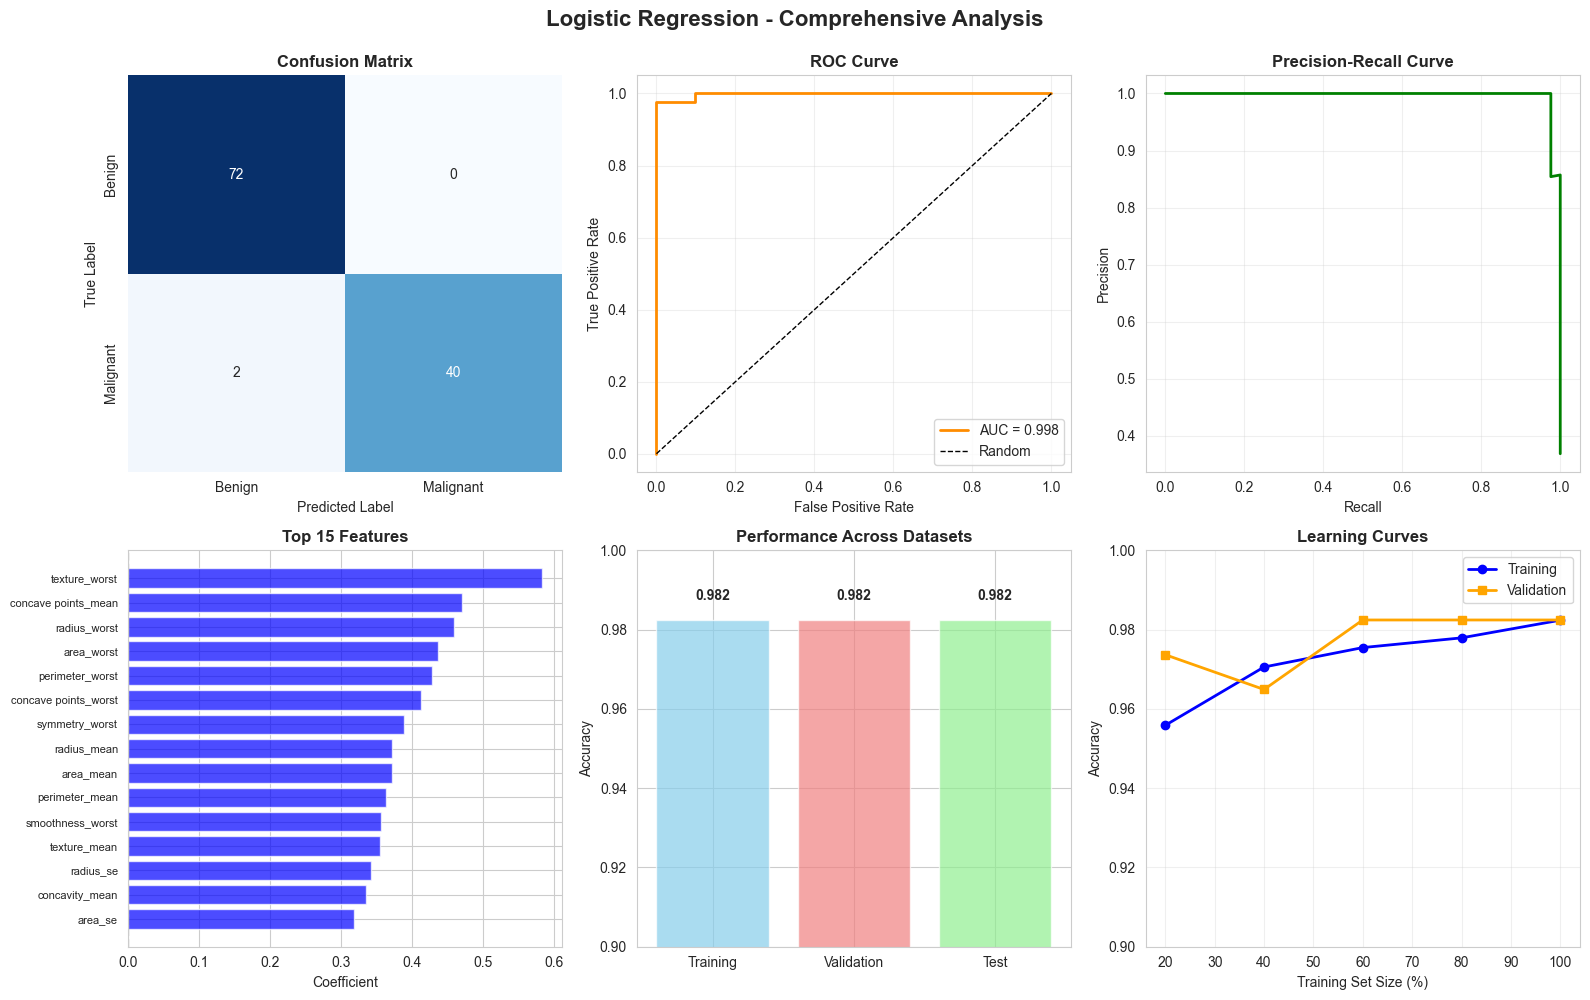

In [30]:
# Create comprehensive visualization dashboard
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# 1. Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0], cbar=False,
            xticklabels=['Benign', 'Malignant'], 
            yticklabels=['Benign', 'Malignant'])
axes[0, 0].set_title('Confusion Matrix', fontweight='bold')
axes[0, 0].set_ylabel('True Label')
axes[0, 0].set_xlabel('Predicted Label')

# 2. ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_test_proba)
axes[0, 1].plot(fpr, tpr, linewidth=2, label=f'AUC = {roc_auc:.3f}', color='darkorange')
axes[0, 1].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')
axes[0, 1].set_xlabel('False Positive Rate')
axes[0, 1].set_ylabel('True Positive Rate')
axes[0, 1].set_title('ROC Curve', fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Precision-Recall Curve
precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_test_proba)
axes[0, 2].plot(recall_vals, precision_vals, linewidth=2, color='green')
axes[0, 2].set_xlabel('Recall')
axes[0, 2].set_ylabel('Precision')
axes[0, 2].set_title('Precision-Recall Curve', fontweight='bold')
axes[0, 2].grid(True, alpha=0.3)

# 4. Feature Importance (Top 15)
top15 = feature_importance.head(15)
colors_feat = ['red' if x < 0 else 'blue' for x in top15['Coefficient']]
axes[1, 0].barh(range(len(top15)), top15['Coefficient'], color=colors_feat, alpha=0.7)
axes[1, 0].set_yticks(range(len(top15)))
axes[1, 0].set_yticklabels(top15['Feature'], fontsize=8)
axes[1, 0].set_xlabel('Coefficient')
axes[1, 0].set_title('Top 15 Features', fontweight='bold')
axes[1, 0].axvline(x=0, color='black', linestyle='--')
axes[1, 0].invert_yaxis()

# 5. Model Performance Comparison
datasets = ['Training', 'Validation', 'Test']
accuracies = [train_acc_opt, val_acc_opt, test_acc_opt]
colors_acc = ['skyblue', 'lightcoral', 'lightgreen']
bars = axes[1, 1].bar(datasets, accuracies, color=colors_acc, alpha=0.7)
axes[1, 1].set_ylabel('Accuracy')
axes[1, 1].set_title('Performance Across Datasets', fontweight='bold')
axes[1, 1].set_ylim([0.9, 1.0])
for bar, acc in zip(bars, accuracies):
    height = bar.get_height()
    axes[1, 1].text(bar.get_x() + bar.get_width()/2., height + 0.005,
                   f'{acc:.3f}', ha='center', fontweight='bold')

# 6. Learning Curves
train_sizes_pct = [20, 40, 60, 80, 100]
axes[1, 2].plot(train_sizes_pct, train_scores_lc, 
               marker='o', linewidth=2, label='Training', color='blue')
axes[1, 2].plot(train_sizes_pct, val_scores_lc, 
               marker='s', linewidth=2, label='Validation', color='orange')
axes[1, 2].set_xlabel('Training Set Size (%)')
axes[1, 2].set_ylabel('Accuracy')
axes[1, 2].set_title('Learning Curves', fontweight='bold')
axes[1, 2].legend()
axes[1, 2].grid(True, alpha=0.3)
axes[1, 2].set_ylim([0.9, 1.0])

plt.suptitle('Logistic Regression - Comprehensive Analysis', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()